Markdown

# Is the average number of goals a good summary?

### A beginner statistical study using Premier League data

*Goal* Explore whether the average goals per match describes the real matches.

*Academic note* This is educational statistics project using public match results only.



Markdown

## Methodology

The analysis followed these steps:

1. Load the Premier League dataset (E0.csv)
2. Create a new variable "total_goals = FTHG + FTAG"
3. Compute the mean total goals per match.
4. Measure how many matches are close to the mean (2 or 3 goals)
5. Compute the standard deviation to describe variability
6. Visualize the distribution of total goals.

This step by step approach follows a basic statistical analysis framework.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
import os
os.getcwd()


'C:\\Users\\dezke\\anaconda_projects\\b0cc8656-e802-480a-b5ca-431047b893a8'

In [4]:
df = pd.read_csv("E0.csv")
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,05/08/2022,20:00,Crystal Palace,Arsenal,0,2,A,0,1,...,1.76,0.50,2.09,1.84,2.04,1.88,2.09,1.88,2.03,1.85
1,E0,06/08/2022,12:30,Fulham,Liverpool,2,2,D,1,0,...,2.73,1.75,1.90,2.03,1.91,2.02,2.01,2.06,1.89,1.99
2,E0,06/08/2022,15:00,Bournemouth,Aston Villa,2,0,H,1,0,...,1.76,0.50,1.93,2.00,1.93,2.00,1.94,2.04,1.88,2.00
3,E0,06/08/2022,15:00,Leeds,Wolves,2,1,H,1,1,...,1.87,-0.25,2.08,1.85,2.10,1.84,2.14,1.87,2.08,1.81
4,E0,06/08/2022,15:00,Newcastle,Nott'm Forest,2,0,H,0,0,...,1.89,-1.00,1.97,1.96,1.99,1.93,2.19,1.97,2.03,1.86


In [5]:
df["total_goals"] = df["FTHG"] + df["FTAG"]
df[["HomeTeam", "AwayTeam", "FTHG", "FTAG", "total_goals"]].head()

,HomeTeam,AwayTeam,FTHG,FTAG,total_goals
0,Crystal Palace,Arsenal,0,2,2
1,Fulham,Liverpool,2,2,4
2,Bournemouth,Aston Villa,2,0,2
3,Leeds,Wolves,2,1,3
4,Newcastle,Nott'm Forest,2,0,2


Markdown

## Home vs Away Goals Analysis

In this section, we compare goals scored by home teams and away teams.

This helps us examine whether playing at home gives teams an advantage.

In [6]:
average_home_goals = df["FTHG"].mean()
average_away_goals = df["FTAG"].mean()

round(average_home_goals, 2), round(average_away_goals, 2)

(np.float64(1.63), np.float64(1.22))

Markdown

## Interpretation

The average number of goals scored by home teams is higher than the average number of goals scored by away teams.

This suggests that teams perform better when playing at home.

In [7]:
average_goals = df["total_goals"].mean()
average_goals

np.float64(2.8526315789473684)

In [8]:
round(average_goals, 2)

np.float64(2.85)

Markdown

## Home vs Away Goals Analysis

In this section, we compare goals scored by home teams and away teams.

This helps us examine whether playing at home gives teams an attacking advantage.

In [9]:
average_home_goals = df["FTHG"].mean()
average_away_goals = df["FTAG"].mean()

round(average_home_goals, 2), round(average_away_goals, 2)

(np.float64(1.63), np.float64(1.22))

Markdown

## Interpretation of Home vs Away Goals

The average number of goals scored by home teams is higher than the average number of goals scored by away teams.

This suggests that teams may have a home advantage when playing in the Premier League.

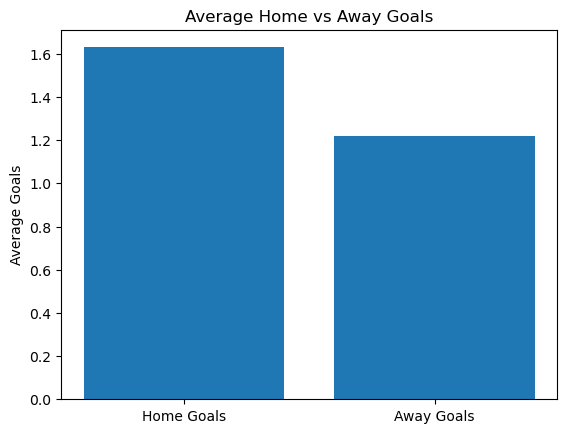

In [10]:
labels = ["Home Goals", "Away Goals"]
values = [round(average_home_goals, 2), round(average_away_goals, 2)]

plt.bar(labels, values)
plt.title("Average Home vs Away Goals")
plt.ylabel("Average Goals")
plt.show()

Markdown

## Visualization Interpretation

The bar chart shows whether home teams score more goals on average than away teams.

This adds a second important variable to the analysis and makes the project statistically richer.

## Match Result Analysis

The variable FTR describes the result of each match:

- H = Home win  
- D = Draw  
- A = Away win

In [11]:
result_counts = df["FTR"].value_counts()
result_counts

FTR
H    184
A    109
D     87
Name: count, dtype: int64

In [12]:
result_prob = df["FTR"].value_counts(normalize=True)
round(result_prob, 2)

FTR
H    0.48
A    0.29
D    0.23
Name: proportion, dtype: float64

## Interpretation of Match Results

The distribution shows how often home teams win, matches end in a draw, or away teams win.

If home wins are more frequent, this supports the idea of home advantage.

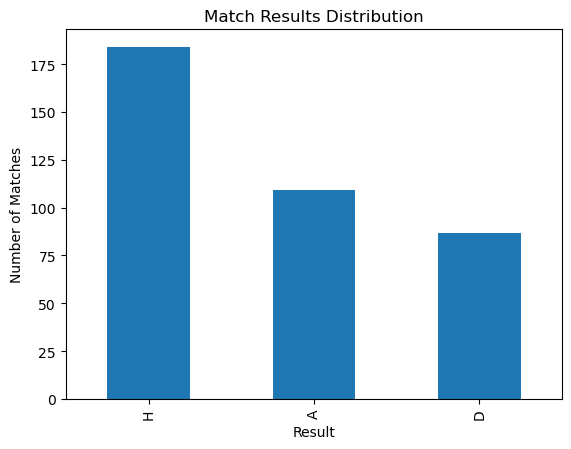

In [13]:
result_counts.plot(kind="bar")
plt.title("Match Results Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

Markdown

## Distribution of Home Goals

The following histogram shows the distribution of goals scored by home teams.

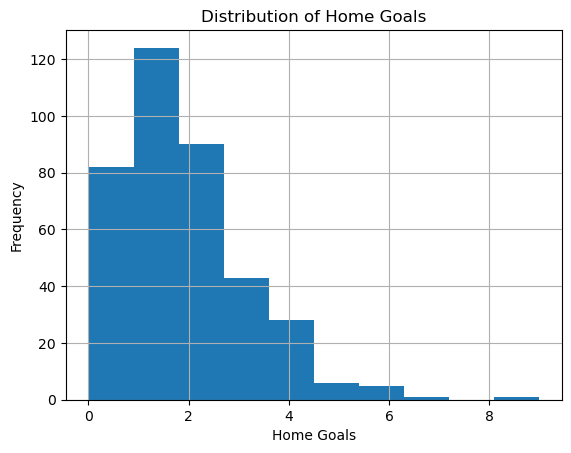

In [14]:
df["FTHG"].hist(bins=10)
plt.title("Distribution of Home Goals")
plt.xlabel("Home Goals")
plt.ylabel("Frequency")
plt.show()

Markdown

## Asymmetry of Home Goals Distribution

The distribution of home goals is slightly right-skewed.

Most home teams score a low or moderate number of goals, while a smaller number of matches contain unusually high home goal counts.

These higher values extend the distribution toward the right.

Markdown 

## Distribution of Away Goals

The following histogram shows the distribution of goals scored by away teams.

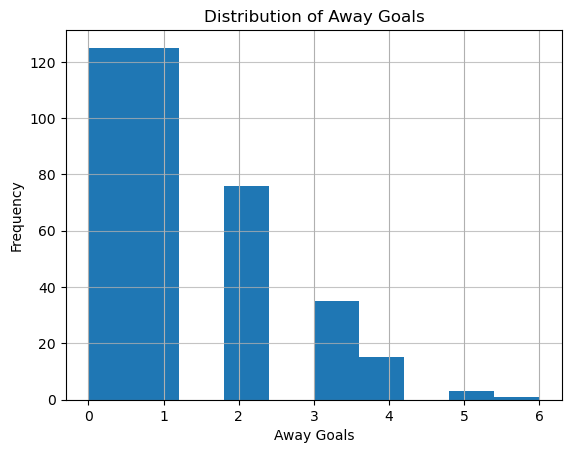

In [24]:
df["FTAG"].hist(bins=10)
plt.title("Distribution of Away Goals")
plt.xlabel("Away Goals")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

Markdown 

## Asymmetry of Away Goals Distribution

The distribution of away goals is also slightly right-skewed.

Most away teams score relatively few goals, while a smaller number of matches include higher away goal counts.

This creates a longer tail on the right side of the distribution.

Markdown

## Interpretation of the Mean

The mean (average) number of goals per match is approximately 2.85.

The mean is calculated by summing all total goals scored in the matches and dividing by the number of matches.

It represents the typical number of goals expected in a Premier League match.

In [15]:
df["total_goals"].value_counts().sort_index()

total_goals
0    23
1    70
2    87
3    79
4    57
5    31
6    18
7    10
8     3
9     2
Name: count, dtype: int64

In [16]:
total_matches = len(df)

prob_2_goals = (df["total_goals"] == 2).sum() / total_matches
prob_3_goals = (df["total_goals"] == 3).sum() / total_matches

round(prob_2_goals, 2), round(prob_3_goals, 2)

(np.float64(0.23), np.float64(0.21))

Markdown

## Probability Interpretation

The probability of a 2-goal match is approximately 0.23 (23%), and the probability of a 3-goal match is approximately 0.21 (21%).

This means that about 23 out of 100 matches end with exactly 2 goals, and about 21 out of 100 matches end with exactly 3 goals.

Since the average is 2.85, and the most common outcomes are 2 and 3 goals, we observe that the mean is close to the most frequent results.

This suggests that the average is a reasonable summary of the data.

In [17]:
close_matches = df[df["total_goals"].isin([2, 3])]
percentage_close = len(close_matches) / len(df)
round(percentage_close, 2)

0.44

Markdown

## Approximately 44% of matches have either 2 or 3 goals.
This means that nearly half of all matches are close to the average (2.85)

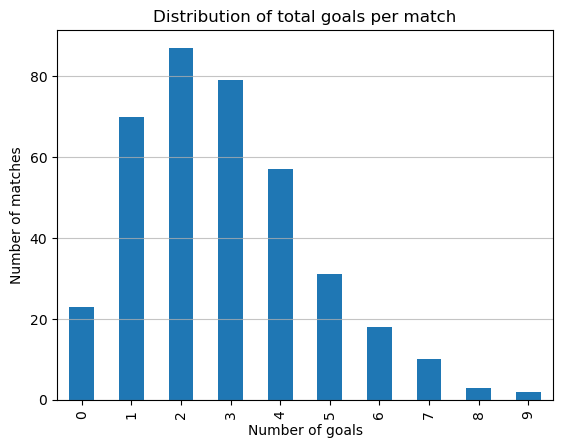

In [23]:
df["total_goals"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of total goals per match")
plt.xlabel("Number of goals")
plt.ylabel("Number of matches")
plt.grid(axis='y', alpha=0.75)
plt.show()

## Asymmetry of the Distribution

The histogram of total goals is slightly right-skewed.

This means that most matches have relatively low or medium numbers of goals, while a smaller number of matches have very high goal counts such as 7, 8, or 9 goals.

These rare high-scoring matches extend the distribution toward the right side.

This indicates that extreme high-scoring matches are rare, but they influence the shape of the distribution and slightly increase the average.


Markdown
## Visual Interpretation
The bar chart shows that the most matches have between 1 and 4 goals.
The highest bars correspond to 2 and 3 goals,
which supports our earlier probability calculations.
Very high-scoring matches (7,8,9 goals) are rare.
The visual evidence supports the idea that the average (2.85) is close to the most common outcome, but it does not capture extreme matches.

In [19]:
df["total_goals"].describe()

count    380.000000
mean       2.852632
std        1.791027
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        9.000000
Name: total_goals, dtype: float64

Markdown

## Distribution of Goals

The distribution of total goals shows that most matches have between 1 and 4 goals.

The highest frequencies occur at 2 and 3 goals, which explains why the mean and median are close to these values.

Very high scoring matches are rare, which slightly extends the distribution toward higher goal values.

Markdown
## Variability in the data
The standard deviation of the total goals is approximately 1.79.
This means that match results typically differ from the average by around 1 to 2 goals.
Although the mean is 2.85, individual matches vary significantly, which confirms that football results are naturally variable.


In [20]:
median_goals = df["total_goals"].median()
median_goals

3.0

Markdown

## Variance

The variance of total goals is approximately 3.21.

Variance measures how spread out the number of goals is around the average.

A larger variance means that match results differ more from the mean.

In [21]:
variance_goals = df["total_goals"].var()
variance_goals

3.207776697680873

Markdown

## Mean vs Median

The median number of goals per match is 3.

The median represents the middle value when all matches are ordered by the total number of goals.

Comparing the mean (2.85) and the median (3) helps us understand the distribution of goals.

Since the mean and median are very close, this suggests that the distribution of goals in this Premier League season is relatively balanced.

Markdown

## Final Conclusion

This project examined whether the average number of goals per match is a good representation of Premier League matches.

The calculated mean was 2.85 goals per match. Additionally, 44% of matches had either 2 or 3 goals, which shows that the average is close to the most common outcomes.

However, the standard deviation is 1.79, indicating that match results vary significantly. Some matches have very few goals, while others have many more than the average.

While many matches are close to the average, the presence of both low-scoring and high-scoring games shows that football outcomes are naturally variable.

Additionally, the comparison between home and away goals and the match result distribution confirms that home advantage plays an important role in match outcomes.

One limitation of this study is that it uses only one season, so the results do not represent the entire history of the league.

Future improvements could include analyzing multiple seasons or using additional statistical measures.

Markdown

## Limitations of the Study

This analysis is based on data from only one Premier League season.

Because of this, the calculated statistics may not represent long-term patterns in the league.

Football results can also be influenced by many factors such as team strength, tactics, injuries, and match conditions, which are not included in this dataset.

Therefore, the results should be interpreted as a simplified statistical exploration rather than a complete model of football performance.

Markdown

## Future Work

Future analysis could include multiple Premier League seasons to obtain more stable statistical estimates.

Additional variables such as team strength, home advantage, or match statistics could also be incorporated to better understand goal patterns.

More advanced statistical models could also be explored to predict match outcomes or expected goals.

Markdown

## Project Summary

This project explored whether the average number of goals per match is a good summary of Premier League match outcomes.

Using match data from one season, several statistical measures were calculated, including the mean, median, variance, and standard deviation.

The analysis showed that the average goals per match (2.85) is close to the most frequent outcomes (2–3 goals), but the variability of match results means that the average alone does not fully describe the distribution of goals.

Overall, the project demonstrates how basic statistical tools can help interpret patterns in sports data.